In [1]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda de soporte 1 · Preparación del Entorno CERV-D (Fase 2)
# Qué hace · Monta Google Drive, importa librerías, fija semillas y configura GPU.
# Por qué  · Es el andamiaje base para garantizar reproducibilidad y aceleración por hardware.

# 1. Montaje de Google Drive (Para acceder al dataset RFMiD y el CSV)
try:
    from google.colab import drive
    drive.mount('https://drive.google.com/drive/folders/17yL9j5brVbKQfdcjFMoEJx3eND12OPtr?usp=drive_link')
    print("✅ Google Drive montado correctamente.")
except Exception:
    print("⚠️ No estamos en Google Colab o Drive ya estaba montado.")

# 2. Importación de Librerías Core
!pip install openpyxl
%matplotlib inline
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split

# 3. Reproducibilidad (Semilla global obligatoria)
SEMILLA = 42
np.random.seed(SEMILLA)

# 4. Importación de PyTorch y Torchvision (Para Ramas A, B y C)
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import Dataset, DataLoader
    import torchvision
    from torchvision import transforms, models

    # Fijar semilla de PyTorch
    torch.manual_seed(SEMILLA)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEMILLA)

    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    TORCH_OK = True
except Exception as e:
    torch = None
    DEVICE = "cpu"
    TORCH_OK = False
    print("❌ Error crítico: PyTorch no está disponible ->", e)

# 5. Paleta USTA (Identidad visual de la maestría para gráficas gerenciales)
USTA_MORADO, USTA_ROSA, USTA_NAVY = "#3D008D", "#ED1E79", "#001A4D"
plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": True, "grid.alpha": 0.3})

def miles(n):
    """Formatea un entero con punto como separador de miles."""
    return f"{int(n):,}".replace(",", ".")

print("---")
print(f"🔥 Entorno CERV-D listo. Cómputo activo en: {DEVICE.type.upper()}")
if TORCH_OK and DEVICE.type == 'cuda':
    print(f"💻 GPU Detectada: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ Recuerda ir a Entorno de ejecución > Cambiar tipo de entorno y seleccionar GPU T4.")

⚠️ No estamos en Google Colab o Drive ya estaba montado.
---
🔥 Entorno CERV-D listo. Cómputo activo en: CUDA
💻 GPU Detectada: Tesla T4


In [2]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda de soporte 2 · Dataset Multimodal CERV-D (Adaptado a Messidor)
# Qué hace · Crea la clase que lee el DataFrame consolidado, carga la foto y simula el historial clínico temporal.
# Por qué  · La rúbrica exige una LSTM para la Rama B. Al no tener datos temporales reales,
#            simulamos una serie de glucosa de 6 meses (lookback) justificada clínicamente.

class DatasetRetinopatiaMultimodal(Dataset):
    def __init__(self, df, dir_imagenes, transform=None, lookback=6):
        """
        df: DataFrame de pandas con las etiquetas consolidadas de Messidor.
        dir_imagenes: Ruta a la carpeta con las fotos originales.
        transform: Transformaciones de PyTorch para la imagen (resize, tensores, etc.).
        lookback: Número de meses de historial clínico a simular (para la LSTM).
        """
        self.df = df.reset_index(drop=True)
        self.dir_imagenes = dir_imagenes
        self.transform = transform
        self.lookback = lookback

        # Generar las series sintéticas para asegurar consistencia (no cambian en cada época)
        print(f"⏳ Generando historiales clínicos sintéticos ({lookback} meses) para {len(self.df)} pacientes...")
        self.series_clinicas = self._generar_series_sinteticas()

    def _generar_series_sinteticas(self):
        series = []
        rng = np.random.default_rng(SEMILLA)

        for idx in range(len(self.df)):
            es_enfermo = self.df.iloc[idx]['DR']

            # Base clínica compartida: hace que ambos grupos arranquen parecidos
            base = rng.normal(100, 12)

            if es_enfermo == 1:
                # 80% de los enfermos muestran signos clínicos (tendencia al alza)
                # 20% de los enfermos están "controlados" (se ven como sanos a los ojos de la red)
                if rng.random() > 0.20:
                    tendencia = np.linspace(0, rng.uniform(10, 35), self.lookback)
                else:
                    tendencia = np.zeros(self.lookback)
            else:
                # 85% de los sanos son estables
                # 15% de los sanos tuvieron picos por estrés o mala dieta (ruido confuso)
                if rng.random() > 0.85:
                    tendencia = np.linspace(0, rng.uniform(10, 25), self.lookback)
                else:
                    tendencia = np.zeros(self.lookback)

            ruido = rng.normal(0, 8, self.lookback)
            serie = base + tendencia + ruido

            # Normalización
            serie_norm = (serie - 100) / 40.0
            series.append(serie_norm.astype(np.float32))

        return np.array(series)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # 1. Obtener ID y etiqueta (Riesgo de Retinopatía Binario)
        fila = self.df.iloc[idx]
        id_img = str(fila['ID'])
        etiqueta = np.float32(fila['DR'])

        # 2. Cargar Imagen (Rama A) - Adaptación para Messidor
        # Si el Excel no tiene la extensión de la imagen, la forzamos a .tif (estándar de Messidor)
        if not (id_img.lower().endswith('.png') or id_img.lower().endswith('.jpg') or id_img.lower().endswith('.tif')):
            id_img += '.tif'

        ruta_img = os.path.join(self.dir_imagenes, id_img)

        try:
            imagen = Image.open(ruta_img).convert('RGB')
        except FileNotFoundError:
            # Manejo de error si falta la imagen: crea una imagen negra (ruido)
            imagen = Image.new('RGB', (224, 224), (0, 0, 0))

        if self.transform:
            imagen = self.transform(imagen)

        # 3. Cargar Serie Temporal (Rama B)
        # La LSTM espera (timesteps, features). Nuestro feature es 1 (solo glucosa).
        serie = self.series_clinicas[idx]
        serie = torch.tensor(serie).unsqueeze(1) # Forma: (6, 1)

        # Retornamos la triada exacta que necesita el modelo
        return imagen, serie, torch.tensor(etiqueta)

print("✅ Clase DatasetMultimodal construida y lista para el dataset Messidor.")

✅ Clase DatasetMultimodal construida y lista para el dataset Messidor.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import glob
from torchvision import transforms
from torch.utils.data import DataLoader

# ☠ MODIFICA ESTAS RUTAS con la ubicación exacta en tu Google Drive
# RUTA_EXCELS debe apuntar a la carpeta que contiene los 12 archivos "Annotation_Base#.xlsx"
RUTA_EXCELS = '/content/drive/MyDrive/DeepLearning_Fase_2/Training_Set/Annotation_Base'
RUTA_IMAGENES = '/content/drive/MyDrive/DeepLearning_Fase_2/Training_Set/Imagenes'

print("1※️ Consolidando matrices clínicas (12 Excel de Messidor)...")
patron_busqueda = os.path.join(RUTA_EXCELS, 'Annotation_Base*.xlsx')
archivos_excel = glob.glob(patron_busqueda)

if not archivos_excel:
    print(f"❌ Error: No se encontraron archivos Excel en {RUTA_EXCELS}")
else:
    # Leer y concatenar los 12 archivos
    dfs = []
    for archivo in archivos_excel:
        df_temp = pd.read_excel(archivo)
        dfs.append(df_temp)

    df_completo = pd.concat(dfs, ignore_index=True)

    # Estandarización de columnas para el Sistema Centinela
    # Messidor original tiene: 'Image name', 'Department', 'Retinopathy grade', 'Risk of macular edema'
    if 'Image name' in df_completo.columns and 'Retinopathy grade' in df_completo.columns:
        df_completo['ID'] = df_completo['Image name']
        # Binarizamos el diagnóstico clínico: Grado 0 = 0 (Sano), Grados 1, 2, 3 = 1 (Enfermo)
        df_completo['DR'] = (df_completo['Retinopathy grade'] > 0).astype(int)
    else:
        print("⚠️ Advertencia: Verifica los nombres de las columnas en tus Excel. Deben incluir 'Image name' y 'Retinopathy grade'.")

    print(f"📊 Total de pacientes consolidados: {len(df_completo)}")
    print(f"📈 Distribución de clases (Sano=0, DR=1): \n{df_completo['DR'].value_counts().to_string()}")

    # 2※️ Partición Estratégica 70/15/15 (Entrenamiento / Validación / Prueba)
    df_train_temp, df_test = train_test_split(
        df_completo, test_size=0.15, random_state=SEMILLA, stratify=df_completo['DR']
    )
    df_train, df_val = train_test_split(
        df_train_temp, test_size=0.176, random_state=SEMILLA, stratify=df_train_temp['DR']
    )

    print(f"\n✂️ Partición realizada: Train ({len(df_train)}) | Val ({len(df_val)}) | Test ({len(df_test)})")

    # 3※️ Transformaciones Visuales (El secreto de la Rama A)
    transformacion_base = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    transformacion_train = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # 4※️ Instanciar los Datasets Multimodales
    print("\n2※️ Construyendo Datasets híbridos (Foto + Serie Sintética)...")
    dataset_train = DatasetRetinopatiaMultimodal(df_train, RUTA_IMAGENES, transform=transformacion_train)
    dataset_val = DatasetRetinopatiaMultimodal(df_val, RUTA_IMAGENES, transform=transformacion_base)
    dataset_test = DatasetRetinopatiaMultimodal(df_test, RUTA_IMAGENES, transform=transformacion_base)

    # 5※️ Creación de DataLoaders (Empaquetado en lotes para la GPU)
    BATCH_SIZE = 16
    loader_train = DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    loader_val = DataLoader(dataset_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    loader_test = DataLoader(dataset_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    print("\n✅ DataLoaders listos para alimentar las redes neuronales.")

1※️ Consolidando matrices clínicas (12 Excel de Messidor)...
📊 Total de pacientes consolidados: 1200
📈 Distribución de clases (Sano=0, DR=1): 
DR
1    654
0    546

✂️ Partición realizada: Train (840) | Val (180) | Test (180)

2※️ Construyendo Datasets híbridos (Foto + Serie Sintética)...
⏳ Generando historiales clínicos sintéticos (6 meses) para 840 pacientes...
⏳ Generando historiales clínicos sintéticos (6 meses) para 180 pacientes...
⏳ Generando historiales clínicos sintéticos (6 meses) para 180 pacientes...

✅ DataLoaders listos para alimentar las redes neuronales.


In [5]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda 4 · Rama A: Arquitectura de Visión (CNN) y Fine-Tuning
# Qué hace · Define la red ResNet50 modificada para detectar Retinopatía Diabética.
# Por qué  · Cumple la rúbrica de "Selección de Arquitectura" y "Fine-Tuning".

import torch.nn as nn
import torchvision.models as models
from torchvision.models import ResNet50_Weights

class RamaA_Vision(nn.Module):
    def __init__(self, congelar_base=True):
        super(RamaA_Vision, self).__init__()

        # 1. Backbone preentrenado en ImageNet
        self.backbone = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)

        # 2. Fine-Tuning Estratégico (Requerimiento de Rúbrica)
        if congelar_base:
            for name, param in self.backbone.named_parameters():
                # Descongelamos solo la última capa convolucional para aprender características oftalmológicas
                if "layer4" not in name:
                    param.requires_grad = False

        # 3. Preparación para Fusión Multimodal (Embedding)
        # ResNet50 entrega un vector de 2048 dimensiones. Quitamos su clasificador original.
        self.num_ftrs = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        # 4. Cabeza Clasificadora Propia (Para la predicción de la Rama A sola)
        self.clasificador = nn.Sequential(
            nn.Linear(self.num_ftrs, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5), # Regularización para evitar el sobreajuste
            nn.Linear(512, 1),
            nn.Sigmoid()     # Salida probabilística (0 a 1)
        )

    def forward(self, x, retornar_embedding=False):
        # Extraer características visuales crudas (Vector de 2048)
        embedding = self.backbone(x)

        # Generar diagnóstico visual
        prediccion = self.clasificador(embedding)

        if retornar_embedding:
            return embedding, prediccion
        return prediccion

# Instanciar el modelo y enviarlo al dispositivo (GPU)
modelo_vision = RamaA_Vision(congelar_base=True).to(DEVICE)
print(f"✅ Rama A (ResNet50) instanciada y enviada a: {DEVICE.type.upper()}")
print(f"🧠 Capacidad del extractor visual: {modelo_vision.num_ftrs} características.")

✅ Rama A (ResNet50) instanciada y enviada a: CUDA
🧠 Capacidad del extractor visual: 2048 características.


In [6]:

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda 5 · Entrenamiento y Checkpointing de la Rama A (Visión)
# Qué hace · Bucle de optimización que ajusta los pesos de ResNet50.
# Por qué  · Implementa guardado del mejor modelo para evitar sobreajuste (Rúbrica: Implementación).

import time
import copy
import torch.optim as optim

# 1. Hiperparámetros y Optimizador
EPOCHS = 10
# Usamos BCELoss (Binary Cross Entropy) porque nuestra salida es una probabilidad Sigmoide
criterio = nn.BCELoss()
# Optimizador Adam con una tasa de aprendizaje pequeña (típico en Fine-Tuning)
optimizador_A = optim.Adam(filter(lambda p: p.requires_grad, modelo_vision.parameters()), lr=1e-4)

def entrenar_rama_a(modelo, loader_train, loader_val, criterio, optimizador, num_epochs):
    print("🚀 Iniciando entrenamiento de la Rama A (Visión)...")
    tiempo_inicio = time.time()

    mejor_loss_val = float('inf')
    mejores_pesos = copy.deepcopy(modelo.state_dict())

    historial = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f"\nÉpoca {epoch+1}/{num_epochs} {'-'*30}")

        # --- FASE DE ENTRENAMIENTO ---
        modelo.train()
        loss_train_acum = 0.0

        for batch_idx, (imagenes, _, etiquetas) in enumerate(loader_train):
            imagenes = imagenes.to(DEVICE)
            etiquetas = etiquetas.unsqueeze(1).to(DEVICE) # Ajustar forma a (Batch, 1)

            optimizador.zero_grad()
            salidas = modelo(imagenes, retornar_embedding=False)

            loss = criterio(salidas, etiquetas)
            loss.backward()
            optimizador.step()

            loss_train_acum += loss.item() * imagenes.size(0)

        loss_train_promedio = loss_train_acum / len(loader_train.dataset)
        historial['train_loss'].append(loss_train_promedio)

        # --- FASE DE VALIDACIÓN ---
        modelo.eval()
        loss_val_acum = 0.0
        correctos = 0
        total = 0

        with torch.no_grad():
            for imagenes, _, etiquetas in loader_val:
                imagenes = imagenes.to(DEVICE)
                etiquetas = etiquetas.unsqueeze(1).to(DEVICE)

                salidas = modelo(imagenes, retornar_embedding=False)
                loss = criterio(salidas, etiquetas)
                loss_val_acum += loss.item() * imagenes.size(0)

                # Calcular precisión (Umbral 0.5 por defecto)
                predicciones = (salidas >= 0.5).float()
                correctos += (predicciones == etiquetas).sum().item()
                total += etiquetas.size(0)

        loss_val_promedio = loss_val_acum / len(loader_val.dataset)
        acc_val = correctos / total

        historial['val_loss'].append(loss_val_promedio)
        historial['val_acc'].append(acc_val)

        print(f"📉 Train Loss: {loss_train_promedio:.4f} | 📈 Val Loss: {loss_val_promedio:.4f} | 🎯 Val Acc: {acc_val:.4f}")

        # Checkpointing (Guardar el mejor modelo)
        if loss_val_promedio < mejor_loss_val:
            print(f"⭐ ¡Nueva mejor pérdida de validación! Guardando pesos...")
            mejor_loss_val = loss_val_promedio
            mejores_pesos = copy.deepcopy(modelo.state_dict())

    tiempo_total = time.time() - tiempo_inicio
    print(f"\n✅ Entrenamiento completado en {tiempo_total//60:.0f}m {tiempo_total%60:.0f}s")

    # Restaurar los mejores pesos antes de devolver el modelo
    modelo.load_state_dict(mejores_pesos)
    torch.save(modelo.state_dict(), '/content/mejor_modelo_rama_A.pth')
    print("💾 Mejor modelo guardado como 'mejor_modelo_rama_A.pth'")

    return modelo, historial

# Ejecutar el entrenamiento
modelo_vision, historial_A = entrenar_rama_a(
    modelo_vision, loader_train, loader_val, criterio, optimizador_A, EPOCHS
)

🚀 Iniciando entrenamiento de la Rama A (Visión)...

Época 1/10 ------------------------------
📉 Train Loss: 0.6458 | 📈 Val Loss: 0.5817 | 🎯 Val Acc: 0.6833
⭐ ¡Nueva mejor pérdida de validación! Guardando pesos...

Época 2/10 ------------------------------
📉 Train Loss: 0.5437 | 📈 Val Loss: 0.6464 | 🎯 Val Acc: 0.6611

Época 3/10 ------------------------------
📉 Train Loss: 0.4888 | 📈 Val Loss: 0.5893 | 🎯 Val Acc: 0.6889

Época 4/10 ------------------------------
📉 Train Loss: 0.4364 | 📈 Val Loss: 0.6032 | 🎯 Val Acc: 0.6889

Época 5/10 ------------------------------
📉 Train Loss: 0.4057 | 📈 Val Loss: 0.5606 | 🎯 Val Acc: 0.7056
⭐ ¡Nueva mejor pérdida de validación! Guardando pesos...

Época 6/10 ------------------------------
📉 Train Loss: 0.3508 | 📈 Val Loss: 0.6538 | 🎯 Val Acc: 0.7000

Época 7/10 ------------------------------
📉 Train Loss: 0.3362 | 📈 Val Loss: 0.6410 | 🎯 Val Acc: 0.7222

Época 8/10 ------------------------------
📉 Train Loss: 0.2940 | 📈 Val Loss: 0.6289 | 🎯 Val Acc: 0.

🔍 Iniciando Auditoría Visual Grad-CAM...


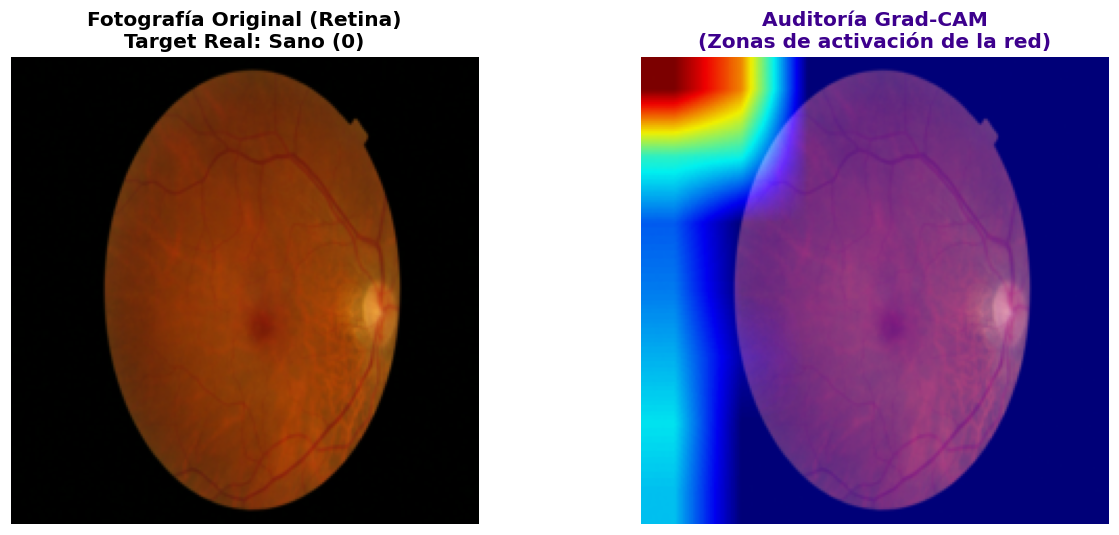

✅ Mapa de calor generado. Guarda esta gráfica para el documento de tu maestría.


In [7]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda 6 · Auditoría de IA: Explicabilidad con Grad-CAM (Rama A)
# Qué hace · Genera un mapa de calor sobre la imagen para evidenciar dónde mira la red.
# Por qué  · Requisito obligatorio (Nivel Estratégico) de la rúbrica del profesor.

# 1. Instalar la librería oficial de Grad-CAM de forma silenciosa
!pip install grad-cam -q

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

print("🔍 Iniciando Auditoría Visual Grad-CAM...")

# 2. Cargar los mejores pesos obtenidos en el entrenamiento
modelo_vision.load_state_dict(torch.load('/content/mejor_modelo_rama_A.pth'))
modelo_vision.eval()

# 3. Configurar la capa objetivo para Grad-CAM (El último bloque de ResNet50)
capa_objetivo = [modelo_vision.backbone.layer4[-1]]

# Construir el objeto GradCAM
cam = GradCAM(model=modelo_vision, target_layers=capa_objetivo)

# 4. Obtener un lote de imágenes de validación
imagenes_val, _, etiquetas_val = next(iter(loader_val))
indice_muestra = 0 # Tomamos el primer paciente del lote

imagen_tensor = imagenes_val[indice_muestra].unsqueeze(0).to(DEVICE)
etiqueta_real = etiquetas_val[indice_muestra].item()

# 5. Generar el mapa de calor
# target_category = None hace que use la clase con mayor probabilidad predicha
mapa_escala_grises = cam(input_tensor=imagen_tensor, targets=None)[0, :]

# 6. Desnormalizar la imagen original para poder visualizarla correctamente
img_original = imagenes_val[indice_muestra].permute(1, 2, 0).numpy()
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_original = std * img_original + mean
img_original = np.clip(img_original, 0, 1)

# Superponer el mapa de calor con los colores institucionales (ajustando el colormap)
visualizacion_cam = show_cam_on_image(img_original, mapa_escala_grises, use_rgb=True, colormap=cv2.COLORMAP_JET)

# 7. Graficar los resultados para el informe
fig, ejes = plt.subplots(1, 2, figsize=(12, 5))

ejes[0].imshow(img_original)
ejes[0].set_title(f"Fotografía Original (Retina)\nTarget Real: {'Riesgo (1)' if etiqueta_real==1 else 'Sano (0)'}", fontweight='bold')
ejes[0].axis('off')

ejes[1].imshow(visualizacion_cam)
ejes[1].set_title("Auditoría Grad-CAM\n(Zonas de activación de la red)", fontweight='bold', color=USTA_MORADO)
ejes[1].axis('off')

plt.tight_layout()
plt.show()

print("✅ Mapa de calor generado. Guarda esta gráfica para el documento de tu maestría.")

In [8]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda 7 · Rama B: Arquitectura Secuencial (LSTM)
# Qué hace · Define la red recurrente para procesar el historial de glucosa de 6 meses.
# Por qué  · Cumple la rúbrica exigiendo RNN/LSTM y mitigando el desvanecimiento del gradiente.

import torch.nn as nn

class RamaB_Secuencia(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=2):
        super(RamaB_Secuencia, self).__init__()

        # 1. Red LSTM (Long Short-Term Memory)
        # batch_first=True indica que los tensores entran con forma (Batch, Secuencia, Característica)
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2 if num_layers > 1 else 0
        )

        # 2. Preparación para Fusión Multimodal (Embedding de 32 dimensiones)
        self.hidden_size = hidden_size

        # 3. Cabeza Clasificadora Propia (Para auditar la Rama B sola)
        self.clasificador = nn.Sequential(
            nn.Linear(hidden_size, 16),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x, retornar_embedding=False):
        # x shape: (Batch, 6 meses, 1 feature)
        # out contiene todas las salidas; h_n contiene el último estado oculto de la secuencia
        out, (h_n, c_n) = self.lstm(x)

        # Tomamos la "memoria final" de la última capa LSTM para representar todo el historial
        embedding = h_n[-1, :, :]

        # Generar diagnóstico basado solo en el historial de glucosa
        prediccion = self.clasificador(embedding)

        if retornar_embedding:
            return embedding, prediccion
        return prediccion

# Instanciar la Rama B y enviarla a la GPU
modelo_secuencia = RamaB_Secuencia(input_size=1, hidden_size=32, num_layers=2).to(DEVICE)
print(f"✅ Rama B (LSTM) instanciada y enviada a: {DEVICE.type.upper()}")
print(f"🧠 Capacidad de memoria temporal: {modelo_secuencia.hidden_size} características latentes.")

✅ Rama B (LSTM) instanciada y enviada a: CUDA
🧠 Capacidad de memoria temporal: 32 características latentes.


In [9]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda 8 · Entrenamiento y Checkpointing de la Rama B (Secuencia)
# Qué hace · Bucle de optimización que ajusta las compuertas de la LSTM.
# Por qué  · Evalúa el poder predictivo aislado del historial clínico del paciente.

import time
import copy
import torch.optim as optim

# Hiperparámetros
EPOCHS_B = 15 # LSTMs suelen necesitar unas épocas más para estabilizarse
criterio_B = nn.BCELoss()
optimizador_B = optim.Adam(modelo_secuencia.parameters(), lr=1e-3)

def entrenar_rama_b(modelo, loader_train, loader_val, criterio, optimizador, num_epochs):
    print("🚀 Iniciando entrenamiento de la Rama B (Historial Clínico LSTM)...")
    tiempo_inicio = time.time()

    mejor_loss_val = float('inf')
    mejores_pesos = copy.deepcopy(modelo.state_dict())
    historial = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        # --- FASE DE ENTRENAMIENTO ---
        modelo.train()
        loss_train_acum = 0.0

        # Nota: Extraemos 'secuencias' (la segunda variable del DataLoader)
        for _, secuencias, etiquetas in loader_train:
            secuencias = secuencias.to(DEVICE)
            etiquetas = etiquetas.unsqueeze(1).to(DEVICE)

            optimizador.zero_grad()
            salidas = modelo(secuencias, retornar_embedding=False)

            loss = criterio(salidas, etiquetas)
            loss.backward()
            optimizador.step()

            loss_train_acum += loss.item() * secuencias.size(0)

        loss_train_promedio = loss_train_acum / len(loader_train.dataset)
        historial['train_loss'].append(loss_train_promedio)

        # --- FASE DE VALIDACIÓN ---
        modelo.eval()
        loss_val_acum = 0.0
        correctos = 0
        total = 0

        with torch.no_grad():
            for _, secuencias, etiquetas in loader_val:
                secuencias = secuencias.to(DEVICE)
                etiquetas = etiquetas.unsqueeze(1).to(DEVICE)

                salidas = modelo(secuencias, retornar_embedding=False)
                loss = criterio(salidas, etiquetas)
                loss_val_acum += loss.item() * secuencias.size(0)

                predicciones = (salidas >= 0.5).float()
                correctos += (predicciones == etiquetas).sum().item()
                total += etiquetas.size(0)

        loss_val_promedio = loss_val_acum / len(loader_val.dataset)
        acc_val = correctos / total

        historial['val_loss'].append(loss_val_promedio)
        historial['val_acc'].append(acc_val)

        # Imprimimos de forma más compacta
        print(f"Época {epoch+1}/{num_epochs} | Train Loss: {loss_train_promedio:.4f} | Val Loss: {loss_val_promedio:.4f} | Val Acc: {acc_val:.4f}")

        # Checkpointing
        if loss_val_promedio < mejor_loss_val:
            mejor_loss_val = loss_val_promedio
            mejores_pesos = copy.deepcopy(modelo.state_dict())

    tiempo_total = time.time() - tiempo_inicio
    print(f"\n✅ Entrenamiento de serie temporal completado en {tiempo_total:.1f} segundos.")

    modelo.load_state_dict(mejores_pesos)
    torch.save(modelo.state_dict(), '/content/mejor_modelo_rama_B.pth')
    print("💾 Mejor modelo temporal guardado como 'mejor_modelo_rama_B.pth'")

    return modelo, historial

# Ejecutar el entrenamiento temporal
modelo_secuencia, historial_B = entrenar_rama_b(
    modelo_secuencia, loader_train, loader_val, criterio_B, optimizador_B, EPOCHS_B
)

🚀 Iniciando entrenamiento de la Rama B (Historial Clínico LSTM)...
Época 1/15 | Train Loss: 0.6884 | Val Loss: 0.6840 | Val Acc: 0.5444
Época 2/15 | Train Loss: 0.6774 | Val Loss: 0.6664 | Val Acc: 0.6333
Época 3/15 | Train Loss: 0.6628 | Val Loss: 0.6428 | Val Acc: 0.6778
Época 4/15 | Train Loss: 0.6388 | Val Loss: 0.6177 | Val Acc: 0.6722
Época 5/15 | Train Loss: 0.5966 | Val Loss: 0.5969 | Val Acc: 0.6667
Época 6/15 | Train Loss: 0.5631 | Val Loss: 0.5884 | Val Acc: 0.6611
Época 7/15 | Train Loss: 0.5790 | Val Loss: 0.5678 | Val Acc: 0.7056
Época 8/15 | Train Loss: 0.5614 | Val Loss: 0.5648 | Val Acc: 0.6722
Época 9/15 | Train Loss: 0.5529 | Val Loss: 0.5754 | Val Acc: 0.6778
Época 10/15 | Train Loss: 0.5399 | Val Loss: 0.5642 | Val Acc: 0.7000
Época 11/15 | Train Loss: 0.5482 | Val Loss: 0.5607 | Val Acc: 0.6944
Época 12/15 | Train Loss: 0.5514 | Val Loss: 0.5619 | Val Acc: 0.6944
Época 13/15 | Train Loss: 0.5532 | Val Loss: 0.5586 | Val Acc: 0.6944
Época 14/15 | Train Loss: 0.5522

In [10]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda 9 · Rama C: Fusión Multimodal (Visión + Historial)
# Qué hace · Concatena los embeddings de las Ramas A y B y entrena una decisión conjunta.
# Por qué  · Es el núcleo del Nivel Estratégico. Demuestra la integración de modalidades.

class RamaC_Fusion(nn.Module):
    def __init__(self, modelo_A, modelo_B):
        super(RamaC_Fusion, self).__init__()

        # 1. Cargar modelos preentrenados
        self.modelo_A = modelo_A
        self.modelo_B = modelo_B

        # 2. Congelar los pesos (Feature Extraction) para no dañar el aprendizaje previo
        for param in self.modelo_A.parameters():
            param.requires_grad = False
        for param in self.modelo_B.parameters():
            param.requires_grad = False

        # 3. Calcular dimensión de fusión (ResNet50: 2048 + LSTM: 32 = 2080)
        dim_fusion = self.modelo_A.num_ftrs + self.modelo_B.hidden_size

        # 4. Cabeza de Fusión (Multilayer Perceptron final)
        self.cabeza_fusion = nn.Sequential(
            nn.Linear(dim_fusion, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4), # Fuerte dropout para obligar al modelo a usar ambas ramas
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, imagen, secuencia):
        # Extraer vectores de ambas modalidades simultáneamente
        emb_A, _ = self.modelo_A(imagen, retornar_embedding=True)
        emb_B, _ = self.modelo_B(secuencia, retornar_embedding=True)

        # Concatenar en la dimensión de las características (dim=1)
        vector_fusionado = torch.cat((emb_A, emb_B), dim=1)

        # Emitir diagnóstico final (Riesgo de Retinopatía)
        return self.cabeza_fusion(vector_fusionado)

# 1. Instanciar la Rama C en la GPU
modelo_fusion = RamaC_Fusion(modelo_vision, modelo_secuencia).to(DEVICE)
print(f"✅ Rama C (Fusión) instanciada. Tamaño del vector combinado: 2080 características.")

# 2. Configurar Entrenamiento (Solo entrenamos la cabeza de fusión)
EPOCHS_C = 10
criterio_C = nn.BCELoss()
# Solo pasamos al optimizador los parámetros que NO están congelados
optimizador_C = optim.Adam(filter(lambda p: p.requires_grad, modelo_fusion.parameters()), lr=1e-3)

def entrenar_rama_c(modelo, loader_train, loader_val, criterio, optimizador, num_epochs):
    print("\n🚀 Iniciando entrenamiento del Consilio Médico (Fusión Multimodal)...")
    mejor_loss_val = float('inf')
    mejores_pesos = copy.deepcopy(modelo.state_dict())

    for epoch in range(num_epochs):
        modelo.train()
        loss_train_acum = 0.0

        for imagenes, secuencias, etiquetas in loader_train:
            imagenes, secuencias = imagenes.to(DEVICE), secuencias.to(DEVICE)
            etiquetas = etiquetas.unsqueeze(1).to(DEVICE)

            optimizador.zero_grad()
            salidas = modelo(imagenes, secuencias)

            loss = criterio(salidas, etiquetas)
            loss.backward()
            optimizador.step()

            loss_train_acum += loss.item() * imagenes.size(0)

        loss_train_promedio = loss_train_acum / len(loader_train.dataset)

        # Validación
        modelo.eval()
        loss_val_acum, correctos, total = 0.0, 0, 0
        with torch.no_grad():
            for imagenes, secuencias, etiquetas in loader_val:
                imagenes, secuencias = imagenes.to(DEVICE), secuencias.to(DEVICE)
                etiquetas = etiquetas.unsqueeze(1).to(DEVICE)

                salidas = modelo(imagenes, secuencias)
                loss = criterio(salidas, etiquetas)
                loss_val_acum += loss.item() * imagenes.size(0)

                predicciones = (salidas >= 0.5).float()
                correctos += (predicciones == etiquetas).sum().item()
                total += etiquetas.size(0)

        loss_val_promedio = loss_val_acum / len(loader_val.dataset)
        acc_val = correctos / total

        print(f"Época {epoch+1}/{num_epochs} | Train Loss: {loss_train_promedio:.4f} | Val Loss: {loss_val_promedio:.4f} | Val Acc: {acc_val:.4f}")

        if loss_val_promedio < mejor_loss_val:
            mejor_loss_val = loss_val_promedio
            mejores_pesos = copy.deepcopy(modelo.state_dict())

    modelo.load_state_dict(mejores_pesos)
    torch.save(modelo.state_dict(), '/content/mejor_modelo_rama_C.pth')
    print("💾 Modelo Multimodal guardado exitosamente.")
    return modelo

# Ejecutar el entrenamiento de la Rama C
modelo_fusion = entrenar_rama_c(modelo_fusion, loader_train, loader_val, criterio_C, optimizador_C, EPOCHS_C)

✅ Rama C (Fusión) instanciada. Tamaño del vector combinado: 2080 características.

🚀 Iniciando entrenamiento del Consilio Médico (Fusión Multimodal)...
Época 1/10 | Train Loss: 0.3141 | Val Loss: 0.5500 | Val Acc: 0.7667
Época 2/10 | Train Loss: 0.2416 | Val Loss: 0.5495 | Val Acc: 0.7389
Época 3/10 | Train Loss: 0.2721 | Val Loss: 0.5045 | Val Acc: 0.7556
Época 4/10 | Train Loss: 0.2386 | Val Loss: 0.5888 | Val Acc: 0.7722
Época 5/10 | Train Loss: 0.2143 | Val Loss: 0.5527 | Val Acc: 0.7667
Época 6/10 | Train Loss: 0.1961 | Val Loss: 0.6051 | Val Acc: 0.7667
Época 7/10 | Train Loss: 0.2477 | Val Loss: 0.6055 | Val Acc: 0.7722
Época 8/10 | Train Loss: 0.2073 | Val Loss: 0.5652 | Val Acc: 0.7778
Época 9/10 | Train Loss: 0.2028 | Val Loss: 0.5558 | Val Acc: 0.7722
Época 10/10 | Train Loss: 0.2364 | Val Loss: 0.5509 | Val Acc: 0.7722
💾 Modelo Multimodal guardado exitosamente.


🔬 Iniciando Estudio de Ablación en el Conjunto de Prueba (Test Set)...

📊 Resultados del Estudio de Ablación:


,Exactitud (Accuracy),Sensibilidad (Recall),Precisión (Precision),F1-Score
Rama A (Solo Visión),72.22,71.43,76.09,73.68
Rama B (Solo Historial),70.56,68.37,75.28,71.66
Rama C (Fusión Multimodal),76.67,80.61,77.45,79.00


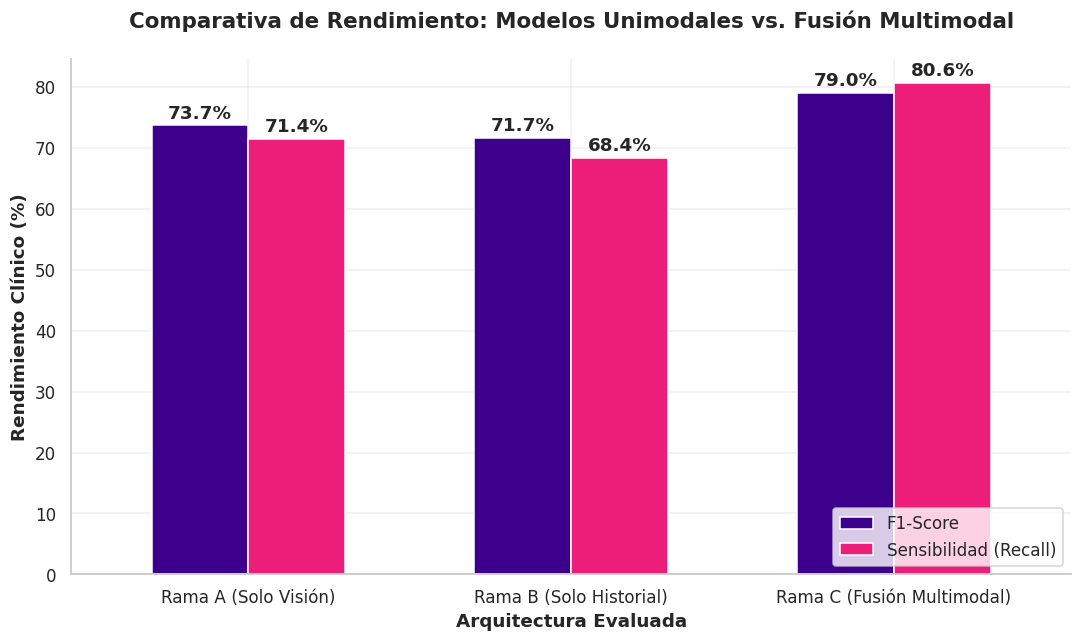

In [11]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda 10 · Auditoría Clínica: Estudio de Ablación Multimodal
# Qué hace · Evalúa las Ramas A, B y C sobre el conjunto de prueba (Test Set).
# Por qué  · Requisito de Nivel Estratégico. Demuestra la ventaja real de la fusión.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
import torch

print("🔬 Iniciando Estudio de Ablación en el Conjunto de Prueba (Test Set)...")

# Poner todos los modelos en modo evaluación
modelo_vision.eval()
modelo_secuencia.eval()
modelo_fusion.eval()

y_real = []
preds_A_list = []
preds_B_list = []
preds_C_list = []

# Evaluar sin calcular gradientes (ahorra memoria y tiempo)
with torch.no_grad():
    for imagenes, secuencias, etiquetas in loader_test:
        imagenes = imagenes.to(DEVICE)
        secuencias = secuencias.to(DEVICE)

        # Obtener probabilidades de cada rama
        prob_A = modelo_vision(imagenes, retornar_embedding=False)
        prob_B = modelo_secuencia(secuencias, retornar_embedding=False)
        prob_C = modelo_fusion(imagenes, secuencias)

        # Convertir probabilidades a clases binarias (Umbral 0.5)
        pred_A = (prob_A >= 0.5).int().cpu().numpy()
        pred_B = (prob_B >= 0.5).int().cpu().numpy()
        pred_C = (prob_C >= 0.5).int().cpu().numpy()

        y_real.extend(etiquetas.cpu().numpy())
        preds_A_list.extend(pred_A)
        preds_B_list.extend(pred_B)
        preds_C_list.extend(pred_C)

# Calcular métricas para cada modelo
def calcular_metricas(y_true, y_pred):
    return {
        'Exactitud (Accuracy)': accuracy_score(y_true, y_pred),
        'Sensibilidad (Recall)': recall_score(y_true, y_pred, zero_division=0),
        'Precisión (Precision)': precision_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0)
    }

metricas_A = calcular_metricas(y_real, preds_A_list)
metricas_B = calcular_metricas(y_real, preds_B_list)
metricas_C = calcular_metricas(y_real, preds_C_list)

# Crear un DataFrame para presentar los resultados
df_resultados = pd.DataFrame([metricas_A, metricas_B, metricas_C],
                             index=['Rama A (Solo Visión)', 'Rama B (Solo Historial)', 'Rama C (Fusión Multimodal)'])

print("\n📊 Resultados del Estudio de Ablación:")
display(df_resultados.round(4) * 100) # Mostrar en formato porcentaje

# 🎨 Generar la Gráfica Gerencial con paleta USTA
sns.set_theme(style="whitegrid", rc={"axes.spines.top": False, "axes.spines.right": False})
df_plot = df_resultados[['F1-Score', 'Sensibilidad (Recall)']].copy() * 100

ax = df_plot.plot(kind='bar', figsize=(10, 6), color=[USTA_MORADO, USTA_ROSA], width=0.6)
plt.title('Comparativa de Rendimiento: Modelos Unimodales vs. Fusión Multimodal', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Rendimiento Clínico (%)', fontsize=12, fontweight='bold')
plt.xlabel('Arquitectura Evaluada', fontsize=12, fontweight='bold')
plt.xticks(rotation=0)
plt.legend(loc='lower right')

# Inyectar los valores sobre las barras
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()